# Binary orbit

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from exogaia.data import EpochAstrometry
from exogaia.leastsq import LeastSquares
from exogaia.models import KeplerModel
from exogaia.results import SamplingResults
from exogaia.samplers import MCMCSampler, NestedSampler

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


In [3]:
np.random.seed(42)

## Gaia epoch astrometry

The ``EpochAstrometry`` class is used for storing Gaia epoch astrometry. For now, we can simulate epoch astrometry for Gaia DR4 or DR5. To do so, we can either set the stellar parameters manually or retrieve parameters from DR3.

In this example, we simulate a binary system by manually providing the stellar parameters. We choose a relatively small orbit such that most of the phase is well sampled by the simulated measurements.

In [4]:
primary_mass = (1.0, 0.1)  # (Msun)
mass_2 = 0.01  # (Msun)
flux_ratio = 0.0

In [5]:
epoch_astrom = EpochAstrometry(primary_mass=primary_mass, gaia_release='DR4')


----------------
Epoch astrometry
----------------

Gaia release: DR4
Reference epoch: 2017.5

Primary mass (Msun): 1.00 +/- 0.10


In [6]:
model_param = {
    'ra': 50.0,
    'dec': 20.0,
    'parallax': 10.0,
    'pm_ra': -30.0,
    'pm_dec': 30.0,
    'g_mag': 7.0,
    'ecc': 0.3,
    'tau': 0.5,
    'inc': np.radians(60.),
    'aop': np.radians(4.),
    'pan': np.radians(90.),
    'sma': 2.,
}

In [7]:
model_param = epoch_astrom.simulate_data(
    model_param=model_param,
    mass_2=mass_2,
    flux_ratio=flux_ratio,
    occ_rate=None,
    sigma_per_ccd=None,
    csv_out=None,
)


-------------
Simulate data
-------------

System type: binary

Primary mass (Msun): 1.00 +/- 0.10

AL scan uncertainty (per CCD) = 159.98 uas
AL scan uncertainty (per transit) = 56.56 uas

Additional parameters:
   - Primary mass (Msun) = 1.00
   - Companion mass (Msun) = 1.00e-02
   - Mass ratio = 1.00e-02
   - Flux ratio = 0.00e+00
   - Relative semi-major axis (au) = 2.00

-----------------------
Calculate stellar track
-----------------------

Stellar parameters:
   - RA offset (mas) = 0.000
   - Dec offset (mas) = 0.000
   - Parallax (mas) = 10.000
   - Proper motion in RA (mas/yr) = -30.000
   - Proper motion in Dec (mas/yr) = 30.000

---------------------
Calculate orbit model
---------------------

Orbit parameters:
   - Period (days) = 1027.956
   - Eccentricity = 0.300
   - Relative time of periastron = 0.500
   - Semi-major axis (mas) = 20.000
   - Inclination (deg) = 60.000
   - Argument of periastron (deg) = 4.000
   - PA of ascending node (deg) = 90.000

Applying AL bia

## Infer parameters with least-squares

In [8]:
leastsq = LeastSquares(epoch_astrometry=epoch_astrom)


--------------------------
Orbit grid (12-parameters)
--------------------------



  0%|          | 0/900 [00:00<?, ?it/s]


Best-fit RUWE = 0.757

Best-fit stellar track:
   - RA offset (mas) = -0.083 +/- 0.021
   - Dec offset (mas) = 0.018 +/- 0.014
   - Parallax (mas) = 9.970 +/- 0.014
   - mu in RA (mas/yr) = -29.986 +/- 0.009
   - mu in Dec (mas/yr) = 30.001 +/- 0.006

Best-fit orbit:
   - Period (days) = 1082.637
   - Eccentricity = 0.600
   - Relative time of periastron = 0.53
   - Thiele-Innes A = 0.009 +/- 0.014
   - Thiele-Innes B = -0.191 +/- 0.019
   - Thiele-Innes F = 0.099 +/- 0.017
   - Thiele-Innes G = 0.075 +/- 0.024

Derived parameters:
   - Semi-major axis of photocenter (mas) = 0.208 +/- 0.021
   - Relative semi-major axis (au) = 2.070
   - Mass function (Msun) = 1.034e-06
   - Companion mass (Msun) = 1.018e-02

Conversion to campbell elements:
   - Period = 1082.637 days
   - Eccentricity = 0.600
   - Relative time of periastron = 0.533
   - Semi-major axis of photocenter (mas) = 0.208
   - Inclination (deg) = 62.987
   - Argument of periastron (deg) = 206.051
   - PA of ascending node 

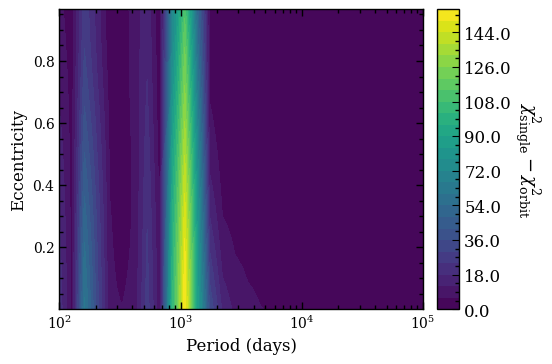

In [9]:
fig = leastsq.orbit_grid(map_type='chi2_det', n_sigma=[3], plot_file='plot.png', n_points=30)


-------------------------
Orbit fit (12 parameters)
-------------------------

Reduced chi^2: 0.270
RUWE: 0.519

Best-fit stellar track:
   - RA offset (mas) = -0.064 +/- 0.061
   - Dec offset (mas) = 0.019 +/- 0.024
   - Parallax (mas) = 9.973 +/- 0.017
   - mu in RA (mas/yr) = -29.987 +/- 0.009
   - mu in Dec (mas/yr) = 30.001 +/- 0.006

Best-fit orbit:
   - Period (days) = 1064.045 +/- 28.757
   - Eccentricity = 0.534 +/- 0.183
   - Relative time of periastron = 0.536 +/- 0.048
   - Semi-major axis of photocenter (mas) = 0.204 +/- 0.022
   - Inclination (deg) = 63.473 +/- 6.247
   - Argument of periastron (deg) = 205.804 +/- 21.914
   - PA of ascending node (deg) = 81.165 +/- 6.801

Number of function evaluations: 10
Number of Jacobian evaluations: 10

Derived parameters:
   - Relative semi-major axis (au) = 2.047
   - Mass function (Msun) = 1.011e-06
   - Companion mass (Msun) = 1.010e-02


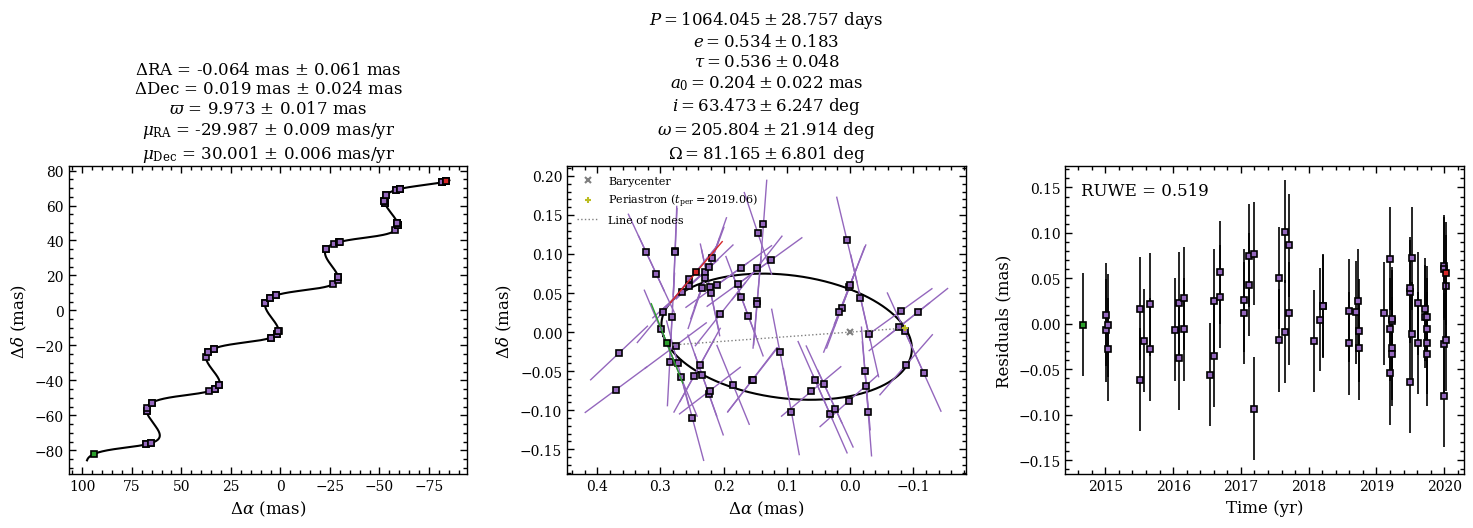

In [10]:
fig = leastsq.orbit_fit(inc_jitter=False, plot_file='plot.png')

In [11]:
print(leastsq)

LeastSquares(Δα = -0.0644025 mas, Δδ = 0.0189752 mas, ϖ = 9.97265 mas, μ_α = -29.9871 mas/yr, μ_δ = 30.0012 mas/yr, P = 1064.05 days, e = 0.534423, τ = 0.536282, a = 0.204133 mas, i = 1.10782 rad, ω = 3.59195 rad, Ω = 1.4166 rad)


## Infer parameters with MCMC

In [12]:
sampler = MCMCSampler(epoch_astrometry=epoch_astrom, least_squares=leastsq)
# sampler = NestedSampler(epoch_astrometry=epoch_astrom, least_squares=leastsq)


------------
MCMC sampler
------------

Primary mass (Msun) = 1.00 +/- 0.10
Number of parameters: 12

Priors:
   - ra_offset -> Normal: [-0.06, 0.10]
   - dec_offset -> Normal: [0.02, 0.10]
   - parallax -> Normal: [9.97, 0.10]
   - pmra -> Normal: [-29.99, 0.10]
   - pmdec -> Normal: [30.00, 0.10]
   - per -> Normal: [1064.05, 28.76]
   - ecc -> Normal: [0.53, 0.18]
   - tau -> Normal: [0.54, 0.05]
   - sma -> Normal: [0.20, 0.02]
   - inc -> Normal: [1.11, 0.11]
   - aop -> Normal: [3.59, 0.38]
   - pan -> Normal: [1.42, 0.12]


In [13]:
sampler.run_ptmcmc(
    pickle_file='exogaia.pkl',
    n_temps=10,
    n_walkers=200,
    n_steps=1000,
    n_sweeps=1,
    progress=True,
)


-------------
Run reddemcee
-------------



100%|████████████████████████████████████████████████████████| 10000/10000 [06:31<00:00, 25.54it/s]
The chain is shorter than 50 times the integrated autocorrelation time for 12 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 20;
tau: [67.06098661 62.59083277 57.08462863 55.9776505  48.97596765 60.1928476
 68.69636104 67.41484465 63.14246945 61.963128   68.02499818 62.32991094]
The chain is shorter than 50 times the integrated autocorrelation time for 12 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 20;
tau: [64.31300579 61.57997446 57.33005143 57.51288224 51.09844236 64.23704215
 67.08096436 63.31648066 64.04105047 64.10219411 63.07533116 61.27339391]
The chain is shorter than 50 times the integrated autocorrelation time for 12 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 20;
tau: [63.63239346 62.84601497 63.17602444 60.31980821 63.16674474 61.2666965
 65.04234219 62.56689154 61.28784892 60.302584

## Plot sampling results

In [14]:
results = SamplingResults(burnin=500, pickle_file='exogaia.pkl')


-----------
Fit results
-----------

Number of parameters: 12
Samples shape: (10, 1000, 200, 12)

Burnin: 500
Samples shape: (10, 500, 200, 12)

Reshaped samples: (1000000, 12)



------------
Plot walkers
------------

Number of walkers: 100
Thin value: 1


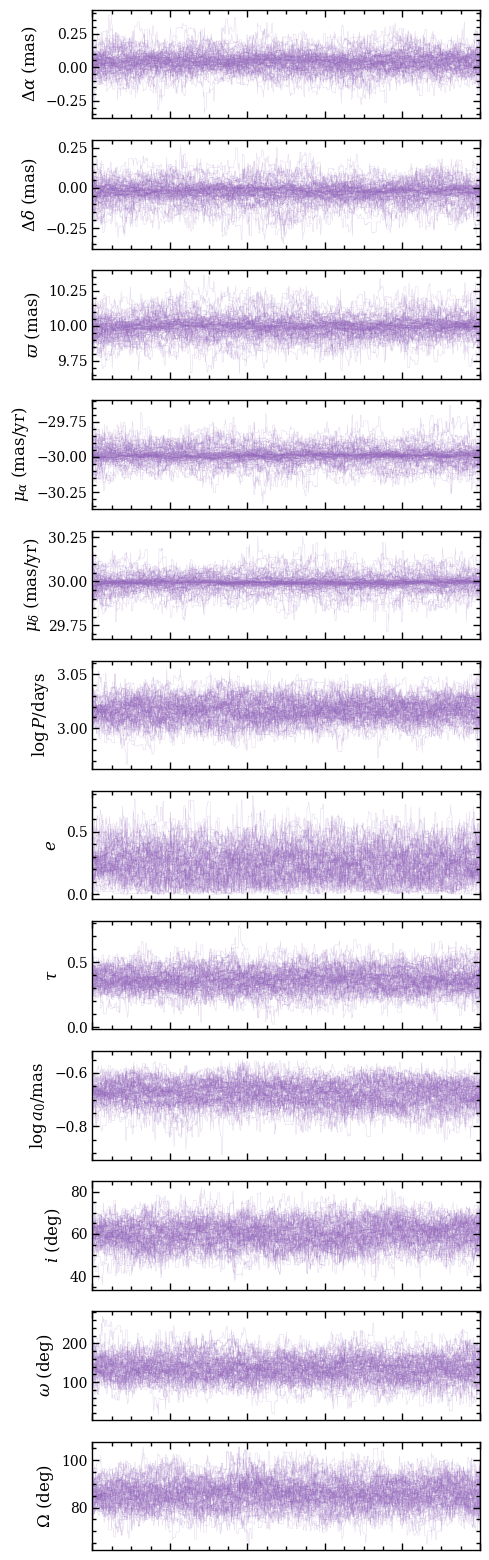

In [15]:
fig = results.plot_walkers(n_walkers=100, thin=None, plot_file=None)


--------------
Plot posterior
--------------

Output file: plot.png


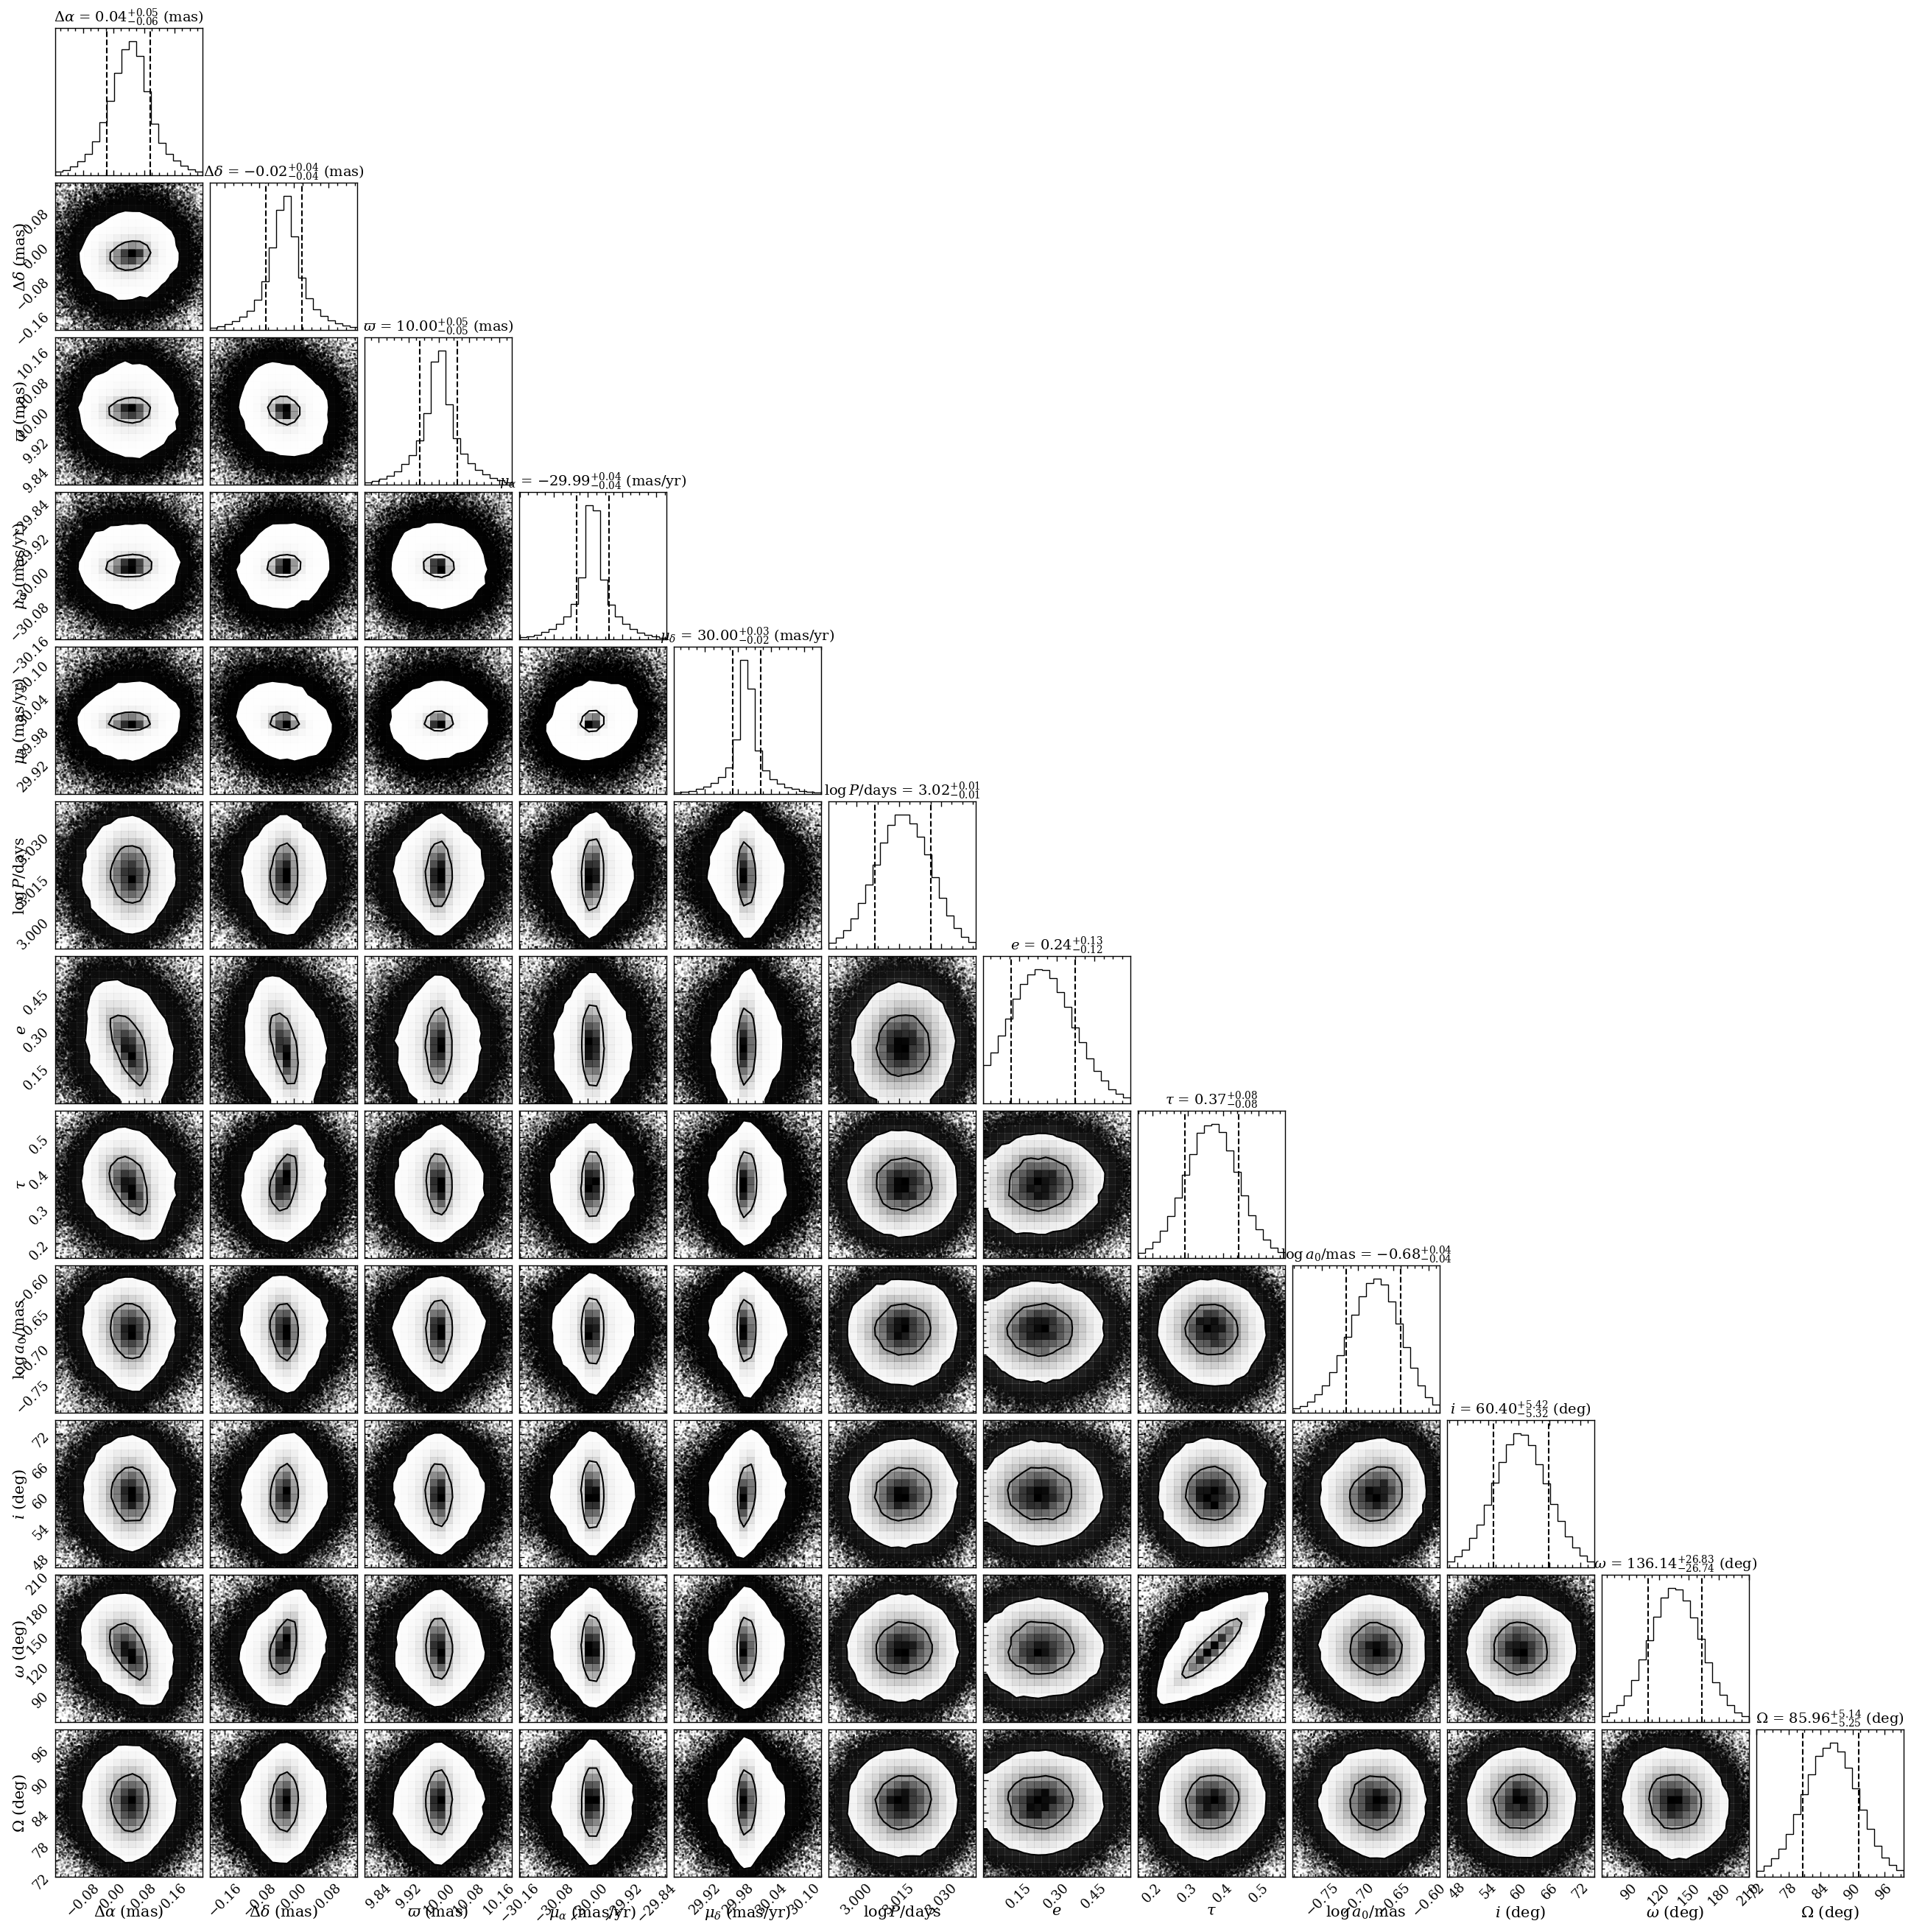

In [16]:
fig = results.plot_posterior(truths=None, plot_file='plot.png')


--------------
Plot residuals
--------------


-----------------------
Calculate stellar track
-----------------------

Stellar parameters:
   - RA offset (mas) = 0.058
   - Dec offset (mas) = -0.026
   - Parallax (mas) = 10.004
   - Proper motion in RA (mas/yr) = -29.992
   - Proper motion in Dec (mas/yr) = 29.994

---------------------
Calculate orbit model
---------------------

Orbit parameters:
   - Period (days) = 1031.274
   - Eccentricity = 0.194
   - Relative time of periastron = 0.307
   - Semi-major axis (mas) = 0.211
   - Inclination (deg) = 60.329
   - Argument of periastron (deg) = 118.029
   - PA of ascending node (deg) = 83.658


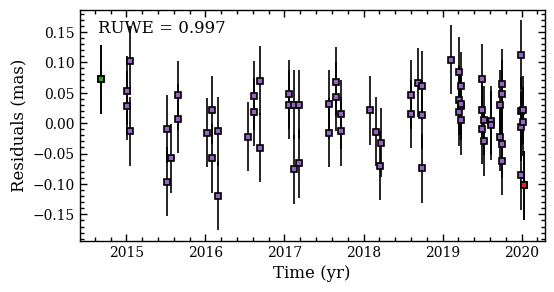

In [17]:
fig = results.plot_residuals(plot_file='plot.png')


----------
Plot orbit
----------



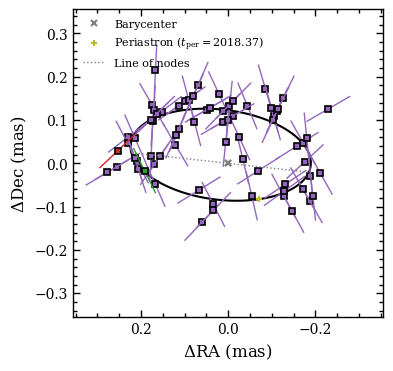

In [18]:
fig = results.plot_orbit(plot_file='plot.png')